# Final Visualizations

"Publication-quality figures for AI infrastructure competitiveness, uncertainty, and behind-the-meter economics."


## Section 1: Setup

This notebook creates final figures from outputs produced by earlier notebooks. It does not introduce new modeling assumptions.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "sources").exists():
    if (PROJECT_ROOT.parent / "sources").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SOURCE_DIR = PROJECT_ROOT / "sources"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False,
})

generated_figures = []


## Section 2: Load Existing Outputs

Notebook 5 outputs are loaded from outputs/tables when available; missing files are reported without stopping the notebook.


In [2]:
def load_csv_if_available(path):
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {path.relative_to(PROJECT_ROOT)}: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    print(f"Missing {path.relative_to(PROJECT_ROOT)}")
    return None

state_competitiveness = load_csv_if_available(
    TABLE_DIR / "state_competitiveness_results.csv"
)

if state_competitiveness is None:
    state_competitiveness = load_csv_if_available(
        TABLE_DIR / "state_competitiveness_ranking.csv"
    )
    if state_competitiveness is not None:
        print("Using state_competitiveness_ranking.csv as the available Notebook 3 ranking output.")

monte_carlo_summary = load_csv_if_available(
    TABLE_DIR / "monte_carlo_summary.csv"
)
monte_carlo_winner_frequency = load_csv_if_available(
    TABLE_DIR / "monte_carlo_winner_frequency.csv"
)
monte_carlo_top3_frequency = load_csv_if_available(
    TABLE_DIR / "monte_carlo_top3_frequency.csv"
)

btm_inputs = load_csv_if_available(SOURCE_DIR / "btm_inputs.csv")

btm_cost_comparison = load_csv_if_available(
    TABLE_DIR / "btm_cost_comparison.csv"
)
architecture_results = load_csv_if_available(
    TABLE_DIR / "architecture_results.csv"
)
break_even_california = load_csv_if_available(
    TABLE_DIR / "break_even_california.csv"
)


Loaded outputs/tables/state_competitiveness_results.csv: 15 rows, 14 columns
Loaded outputs/tables/monte_carlo_summary.csv: 15 rows, 6 columns
Loaded outputs/tables/monte_carlo_winner_frequency.csv: 15 rows, 2 columns
Loaded outputs/tables/monte_carlo_top3_frequency.csv: 15 rows, 2 columns
Loaded sources/btm_inputs.csv: 6 rows, 5 columns
Loaded outputs/tables/btm_cost_comparison.csv: 6 rows, 11 columns
Loaded outputs/tables/architecture_results.csv: 6 rows, 7 columns
Loaded outputs/tables/break_even_california.csv: 100 rows, 5 columns


## Section 3: Figure 1 - State Competitiveness Ranking


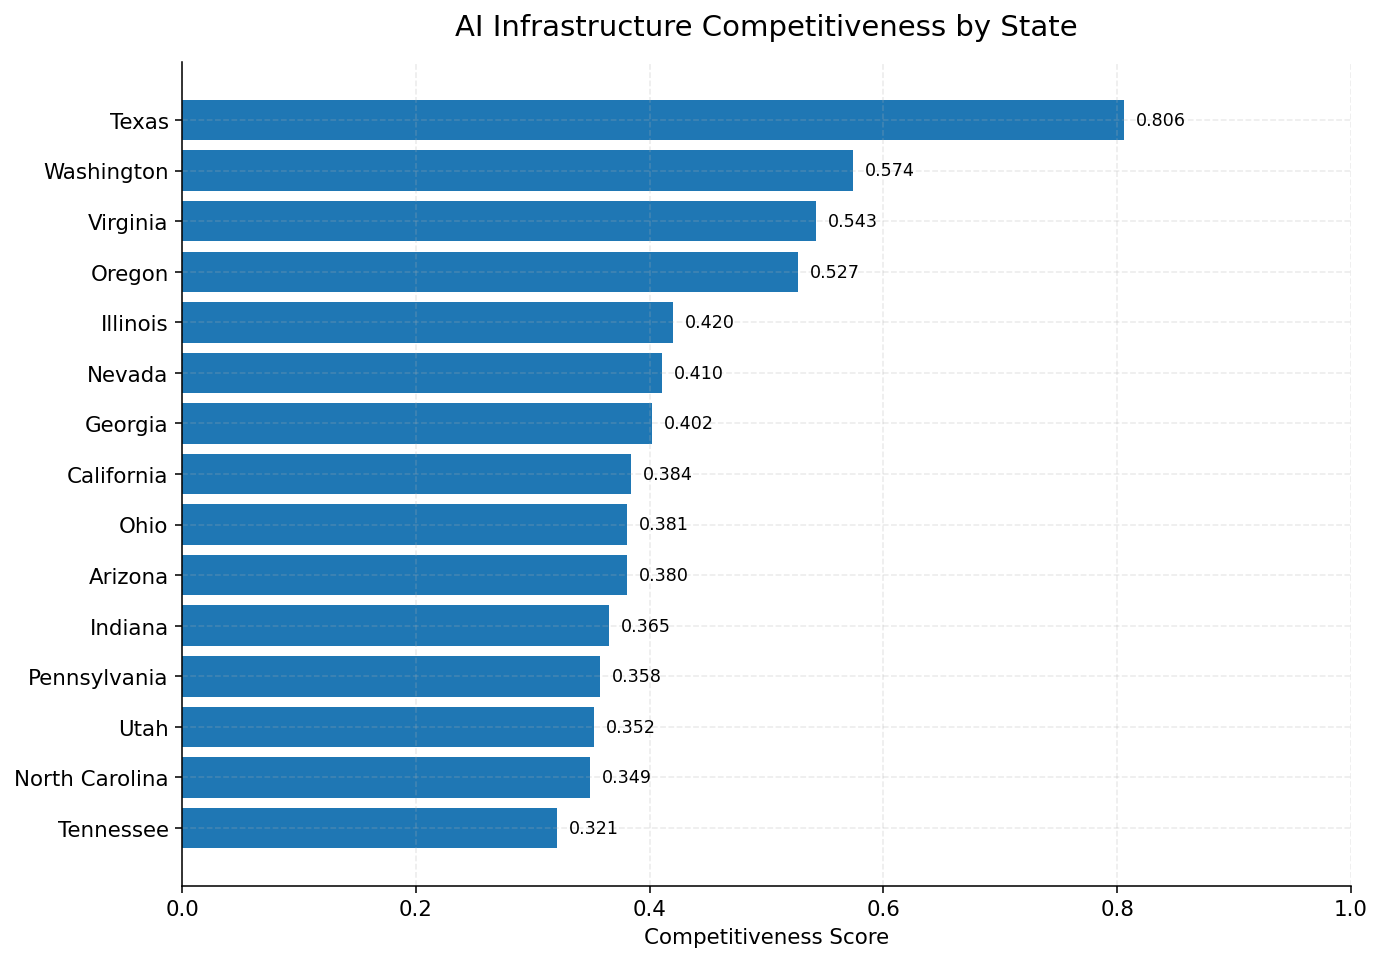

In [3]:
if state_competitiveness is not None and {"State", "competitiveness_score"}.issubset(state_competitiveness.columns):
    plot_data = (
        state_competitiveness[["State", "competitiveness_score"]]
        .dropna()
        .sort_values("competitiveness_score", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["State"],
        plot_data["competitiveness_score"]
    )
    ax.set_title("AI Infrastructure Competitiveness by State", pad=14)
    ax.set_xlabel("Competitiveness Score")
    ax.set_ylabel("")
    ax.set_xlim(0, max(1.0, plot_data["competitiveness_score"].max() * 1.08))

    for value, state in zip(plot_data["competitiveness_score"], plot_data["State"]):
        ax.text(value + 0.01, state, f"{value:.3f}", va="center", fontsize=9)

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig1_state_competitiveness_ranking.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 1 skipped: state competitiveness output with State and competitiveness_score is unavailable.")


## Section 4: Figure 2 - Monte Carlo Winner Frequency


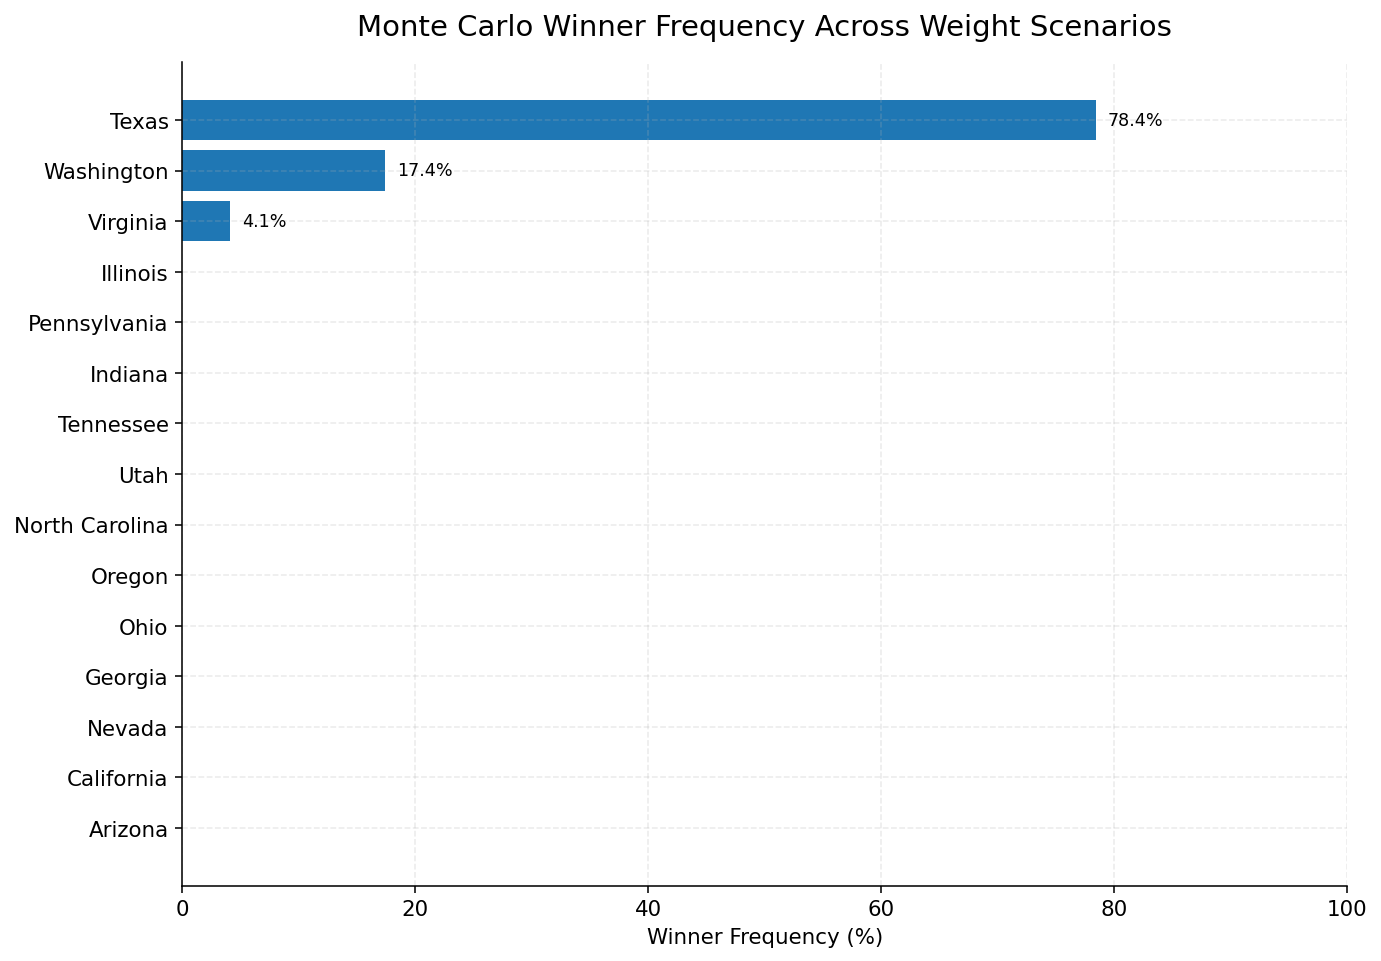

In [4]:
required_cols = {"State", "Winner_Frequency_Percent"}
if monte_carlo_winner_frequency is not None and required_cols.issubset(monte_carlo_winner_frequency.columns):
    plot_data = (
        monte_carlo_winner_frequency[["State", "Winner_Frequency_Percent"]]
        .dropna()
        .sort_values("Winner_Frequency_Percent", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["State"],
        plot_data["Winner_Frequency_Percent"]
    )
    ax.set_title("Monte Carlo Winner Frequency Across Weight Scenarios", pad=14)
    ax.set_xlabel("Winner Frequency (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(100, plot_data["Winner_Frequency_Percent"].max() * 1.12))

    for value, state in zip(plot_data["Winner_Frequency_Percent"], plot_data["State"]):
        if value >= 0.05:
            ax.text(value + 1, state, f"{value:.1f}%", va="center", fontsize=9)

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig2_monte_carlo_winner_frequency.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 2 skipped: Monte Carlo winner frequency output is unavailable.")


## Section 5: Figure 3 - Strength vs Robustness


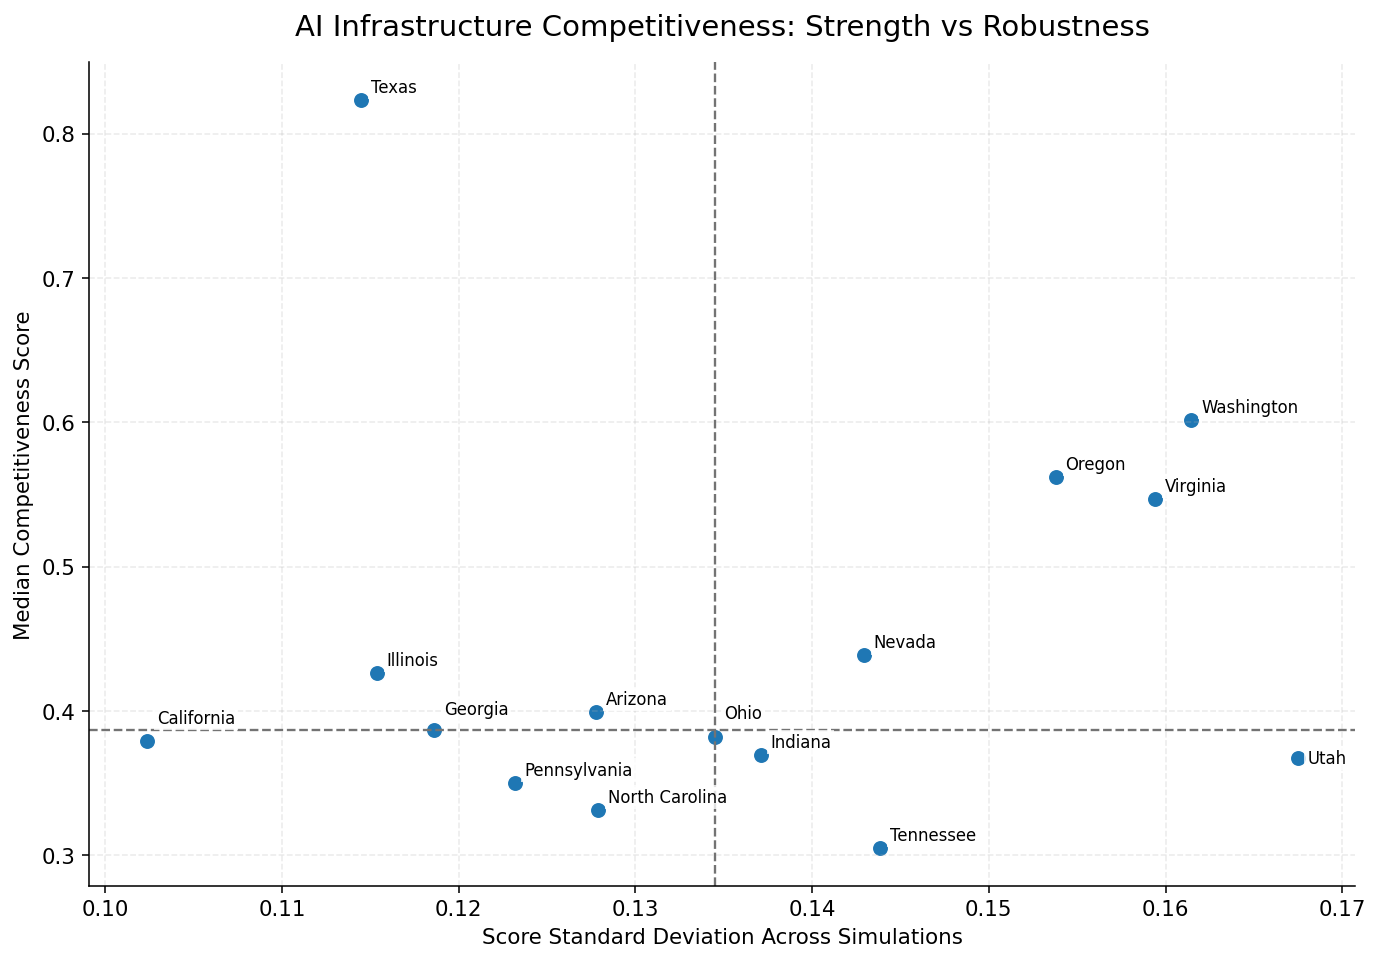

In [5]:
required_cols = {"State", "median_score", "std_score"}
if monte_carlo_summary is not None and required_cols.issubset(monte_carlo_summary.columns):
    plot_data = monte_carlo_summary[["State", "median_score", "std_score"]].dropna().copy()

    x_median = plot_data["std_score"].median()
    y_median = plot_data["median_score"].median()

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(
        plot_data["std_score"],
        plot_data["median_score"],
        s=72,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.axvline(x_median, color="0.45", linestyle="--", linewidth=1.2)
    ax.axhline(y_median, color="0.45", linestyle="--", linewidth=1.2)

    label_offsets = {
        "California": (5, 9),
        "Ohio": (5, 10),
        "Georgia": (5, 8),
        "Utah": (5, -3),
    }

    for _, row in plot_data.iterrows():
        ax.annotate(
            row["State"],
            (row["std_score"], row["median_score"]),
            xytext=label_offsets.get(row["State"], (5, 4)),
            textcoords="offset points",
            fontsize=8.5,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.5},
        )

    ax.set_title("AI Infrastructure Competitiveness: Strength vs Robustness", pad=14)
    ax.set_xlabel("Score Standard Deviation Across Simulations")
    ax.set_ylabel("Median Competitiveness Score")

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig3_strength_vs_robustness.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 3 skipped: Monte Carlo summary output is unavailable.")


## Section 6: Figure 4 - Top-3 Frequency


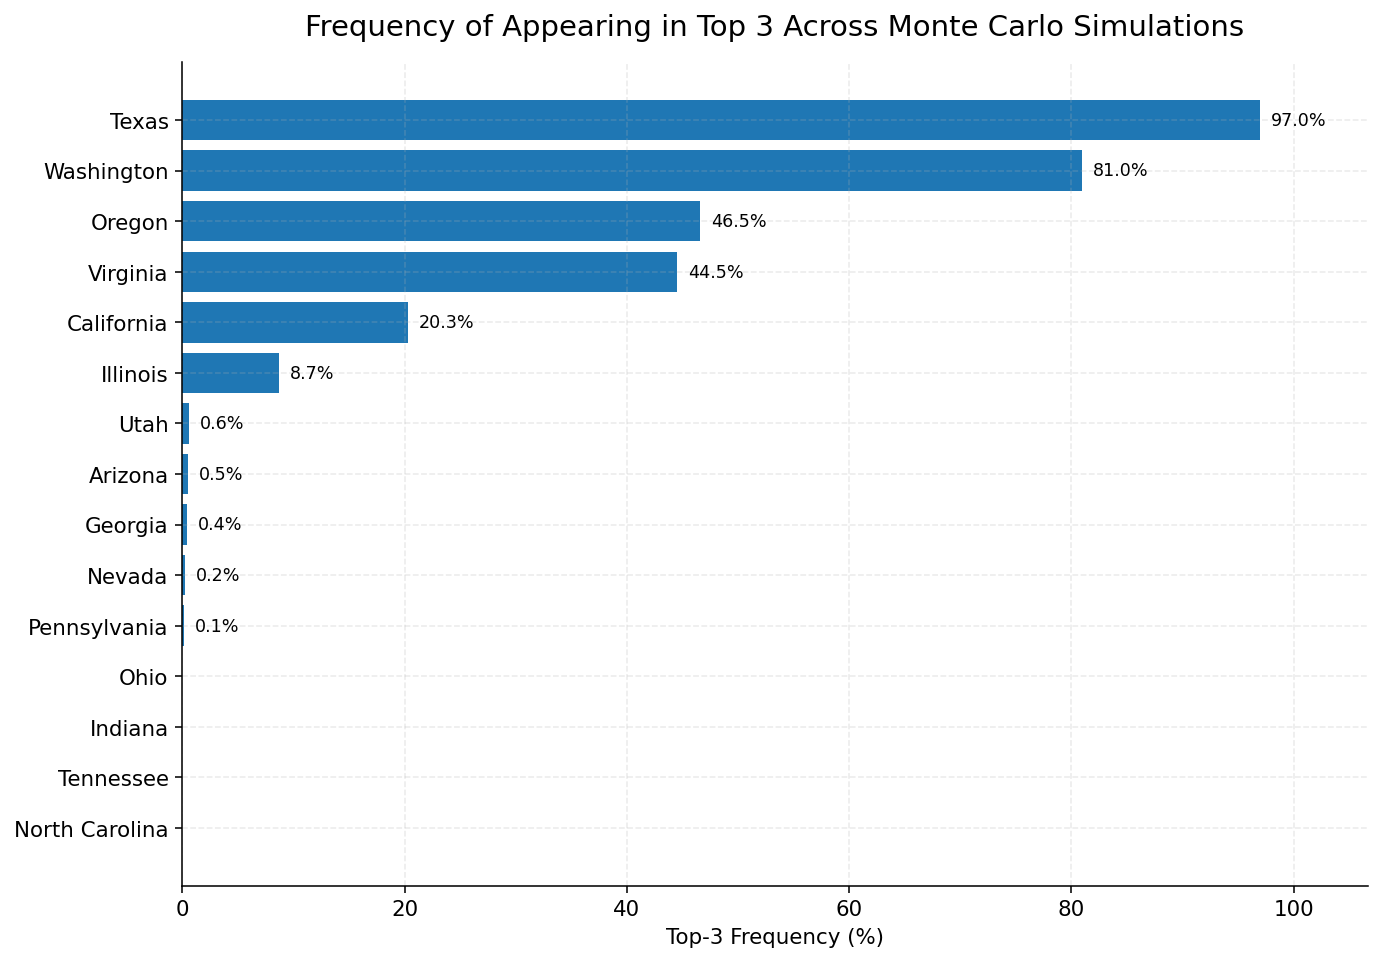

In [6]:
required_cols = {"State", "Top_3_Frequency_Percent"}
if monte_carlo_top3_frequency is not None and required_cols.issubset(monte_carlo_top3_frequency.columns):
    plot_data = (
        monte_carlo_top3_frequency[["State", "Top_3_Frequency_Percent"]]
        .dropna()
        .sort_values("Top_3_Frequency_Percent", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["State"],
        plot_data["Top_3_Frequency_Percent"]
    )
    ax.set_title("Frequency of Appearing in Top 3 Across Monte Carlo Simulations", pad=14)
    ax.set_xlabel("Top-3 Frequency (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(100, plot_data["Top_3_Frequency_Percent"].max() * 1.10))

    for value, state in zip(plot_data["Top_3_Frequency_Percent"], plot_data["State"]):
        if value >= 0.05:
            ax.text(value + 1, state, f"{value:.1f}%", va="center", fontsize=9)

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig4_top3_frequency.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 4 skipped: Monte Carlo top-3 frequency output is unavailable.")


## Section 7: Figure 5 - Power Cost Architecture Comparison

Notebook 5 should export `outputs/tables/btm_cost_comparison.csv` before final publication.


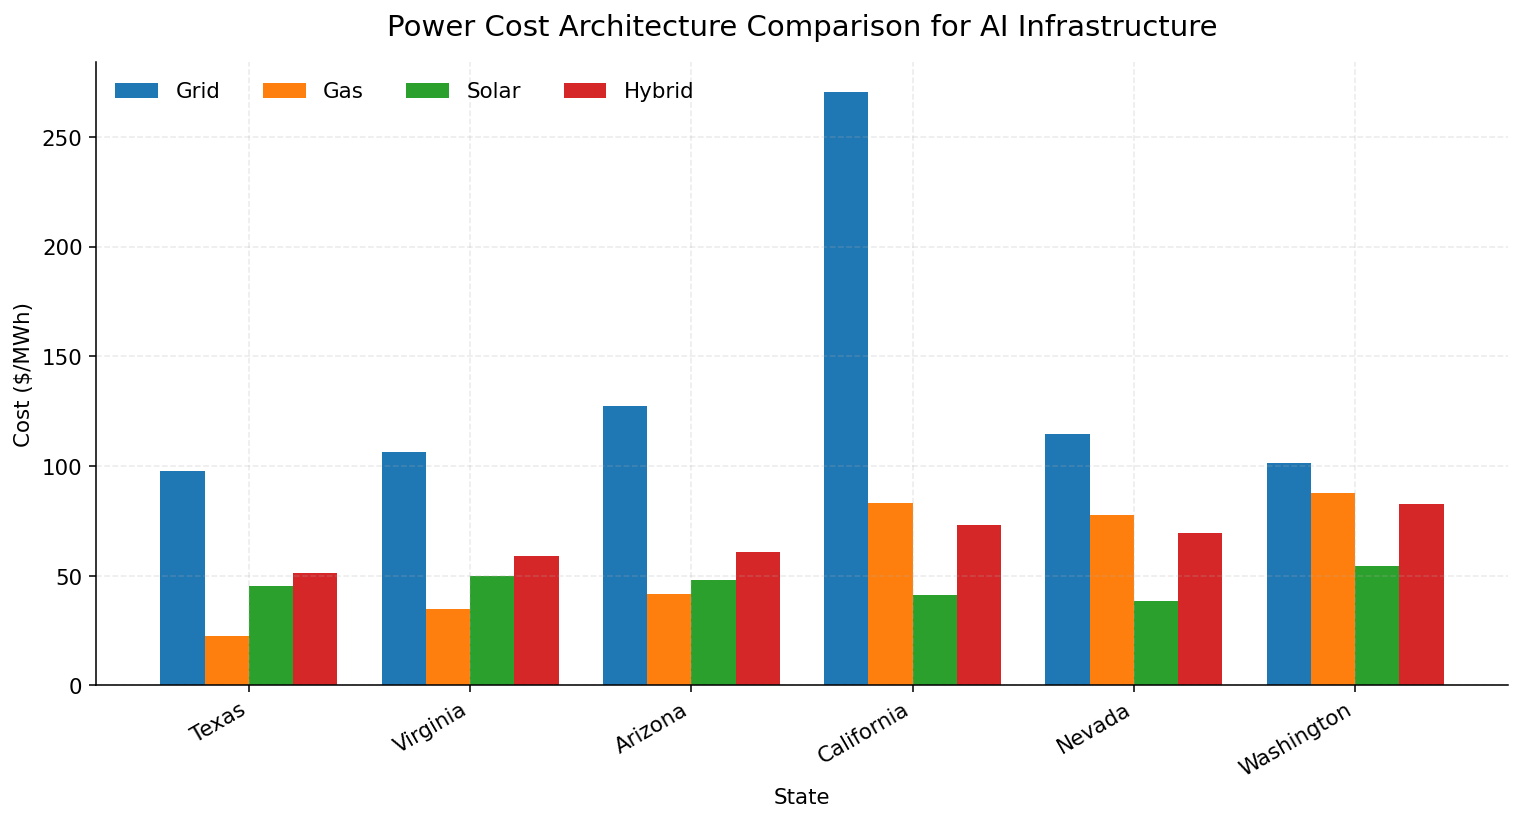

In [7]:
architecture_cost_cols = [
    "grid_cost_usd_per_mwh",
    "gas_cost_usd_per_mwh",
    "solar_cost_usd_per_mwh",
    "hybrid_cost_usd_per_mwh",
]
required_cols = {"State", *architecture_cost_cols}

if btm_cost_comparison is not None and required_cols.issubset(btm_cost_comparison.columns):
    plot_data = btm_cost_comparison[["State", *architecture_cost_cols]].copy()
    x = np.arange(len(plot_data))
    width = 0.20

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = [
        ("Grid", "grid_cost_usd_per_mwh", "C0", -1.5),
        ("Gas", "gas_cost_usd_per_mwh", "C1", -0.5),
        ("Solar", "solar_cost_usd_per_mwh", "C2", 0.5),
        ("Hybrid", "hybrid_cost_usd_per_mwh", "C3", 1.5),
    ]

    for label, col, color, offset in bars:
        ax.bar(x + offset * width, plot_data[col], width, label=label, color=color)

    ax.set_title("Power Cost Architecture Comparison for AI Infrastructure", pad=14)
    ax.set_xlabel("State")
    ax.set_ylabel("Cost ($/MWh)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data["State"], rotation=30, ha="right")
    ax.legend(ncol=4, loc="upper left")

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig5_power_cost_architecture_comparison.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 5 skipped: outputs/tables/btm_cost_comparison.csv is unavailable or missing architecture cost columns.")


## Section 8: Figure 6 - Optimal Power Architecture by State

Notebook 5 should export `outputs/tables/architecture_results.csv` before final publication.


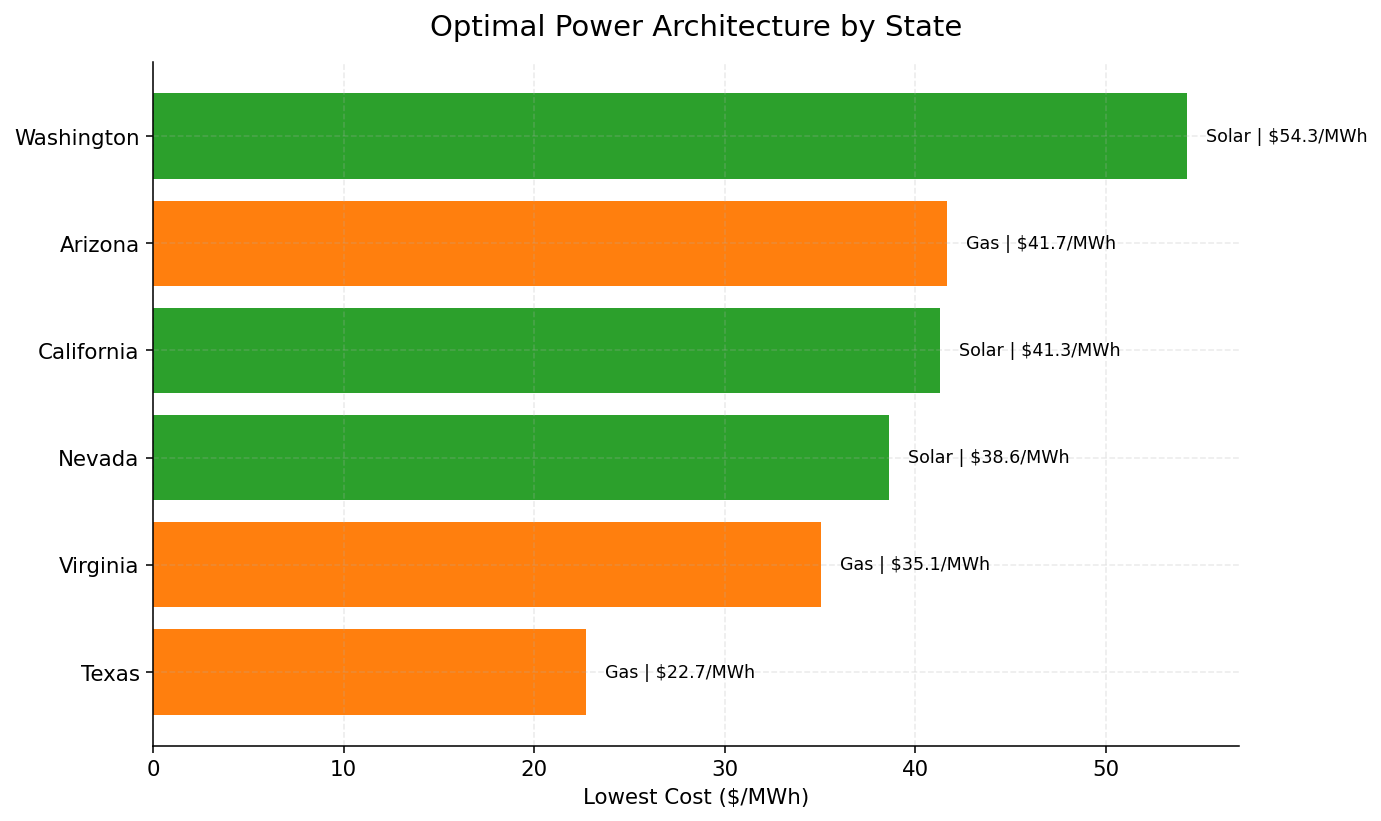

In [8]:
required_cols = {"State", "best_architecture", "lowest_cost_usd_per_mwh"}
if architecture_results is not None and required_cols.issubset(architecture_results.columns):
    plot_data = (
        architecture_results[["State", "best_architecture", "lowest_cost_usd_per_mwh"]]
        .dropna()
        .sort_values("lowest_cost_usd_per_mwh", ascending=True)
    )

    palette = {
        "Grid": "C0",
        "Gas": "C1",
        "Solar": "C2",
        "Hybrid": "C3",
    }
    bar_colors = [palette.get(value, "0.5") for value in plot_data["best_architecture"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_data["State"], plot_data["lowest_cost_usd_per_mwh"], color=bar_colors)
    ax.set_title("Optimal Power Architecture by State", pad=14)
    ax.set_xlabel("Lowest Cost ($/MWh)")
    ax.set_ylabel("")

    for _, row in plot_data.iterrows():
        ax.text(
            row["lowest_cost_usd_per_mwh"] + 1,
            row["State"],
            f"{row['best_architecture']} | ${row['lowest_cost_usd_per_mwh']:.1f}/MWh",
            va="center",
            fontsize=9,
        )

    fig.tight_layout()
    output_path = FIGURE_DIR / "fig6_optimal_power_architecture.png"
    fig.savefig(output_path, bbox_inches="tight")
    generated_figures.append(output_path)
    plt.show()
else:
    print("Figure 6 skipped: outputs/tables/architecture_results.csv is unavailable or missing required columns.")


## Section 9: Figure 7 - Break-Even Curve

Notebook 5 should export `outputs/tables/break_even_california.csv` before final publication.


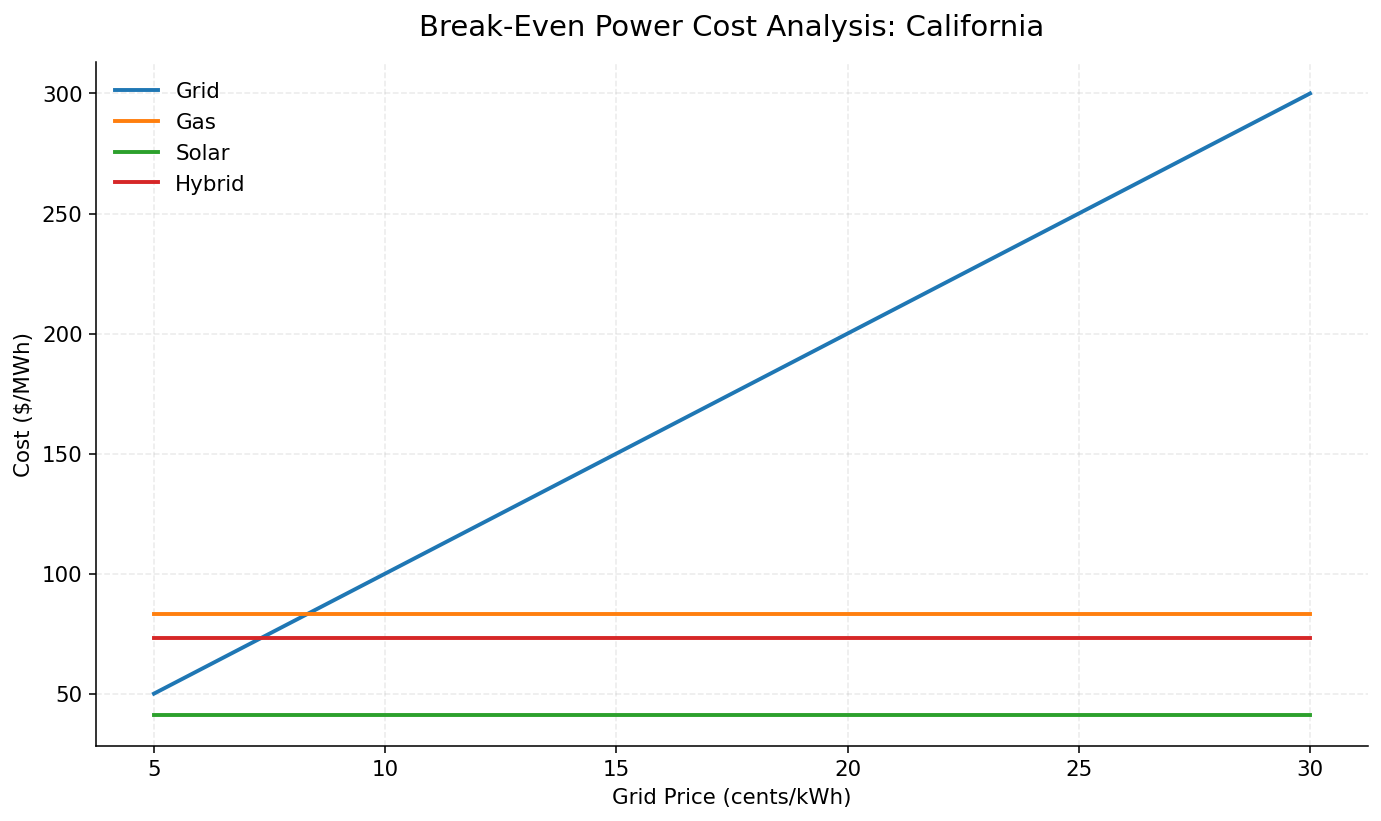

In [9]:
if break_even_california is not None:
    cost_cols = [
        col for col in [
            "grid_cost_usd_per_mwh",
            "gas_cost_usd_per_mwh",
            "solar_cost_usd_per_mwh",
            "hybrid_cost_usd_per_mwh",
        ]
        if col in break_even_california.columns
    ]

    if "grid_price_cents_per_kwh" in break_even_california.columns and cost_cols:
        fig, ax = plt.subplots(figsize=(10, 6))
        labels = {
            "grid_cost_usd_per_mwh": "Grid",
            "gas_cost_usd_per_mwh": "Gas",
            "solar_cost_usd_per_mwh": "Solar",
            "hybrid_cost_usd_per_mwh": "Hybrid",
        }
        colors = {
            "grid_cost_usd_per_mwh": "C0",
            "gas_cost_usd_per_mwh": "C1",
            "solar_cost_usd_per_mwh": "C2",
            "hybrid_cost_usd_per_mwh": "C3",
        }

        for col in cost_cols:
            ax.plot(
                break_even_california["grid_price_cents_per_kwh"],
                break_even_california[col],
                label=labels[col],
                linewidth=2,
                color=colors[col],
            )

        ax.set_title("Break-Even Power Cost Analysis: California", pad=14)
        ax.set_xlabel("Grid Price (cents/kWh)")
        ax.set_ylabel("Cost ($/MWh)")
        ax.legend(loc="upper left")

        fig.tight_layout()
        output_path = FIGURE_DIR / "fig7_break_even_california.png"
        fig.savefig(output_path, bbox_inches="tight")
        generated_figures.append(output_path)
        plt.show()
    else:
        print("Figure 7 skipped: break-even table does not contain grid_price_cents_per_kwh and cost columns.")
else:
    print("Figure 7 skipped: outputs/tables/break_even_california.csv is unavailable.")


## Section 10: Final Figure Inventory

| Figure | Output file | What it communicates |
| --- | --- | --- |
| Figure 1 | `fig1_state_competitiveness_ranking.png` | Final state competitiveness ranking from the saved Notebook 3 output. |
| Figure 2 | `fig2_monte_carlo_winner_frequency.png` | How often each state wins across Monte Carlo weight scenarios. |
| Figure 3 | `fig3_strength_vs_robustness.png` | Median competitiveness strength versus score volatility across simulations. |
| Figure 4 | `fig4_top3_frequency.png` | How often each state appears in the top three across Monte Carlo scenarios. |
| Figure 5 | `fig5_power_cost_architecture_comparison.png` | Grid, gas, solar, and hybrid cost comparison when Notebook 5 exports are available. |
| Figure 6 | `fig6_optimal_power_architecture.png` | Lowest-cost architecture by state when Notebook 5 architecture results are available. |
| Figure 7 | `fig7_break_even_california.png` | California break-even power cost curve when Notebook 5 break-even output is available. |

If Figures 5-7 are skipped in a future run, export `btm_cost_comparison.csv`, `architecture_results.csv`, and `break_even_california.csv` from Notebook 5 into `outputs/tables`.


In [10]:
print("Generated figures:")
if generated_figures:
    for path in generated_figures:
        print(f"- {path.relative_to(PROJECT_ROOT)}")
else:
    print("No figures were generated. Check the missing table messages above.")


Generated figures:
- outputs/figures/fig1_state_competitiveness_ranking.png
- outputs/figures/fig2_monte_carlo_winner_frequency.png
- outputs/figures/fig3_strength_vs_robustness.png
- outputs/figures/fig4_top3_frequency.png
- outputs/figures/fig5_power_cost_architecture_comparison.png
- outputs/figures/fig6_optimal_power_architecture.png
- outputs/figures/fig7_break_even_california.png
